![banner](https://raw.githubusercontent.com/semilleroCV/Hands-on-Computer-Vision/refs/heads/main/sesiones/sesion9/Sesion9-banner.png)

---

### ¿Qué vamos a hacer?

Un problema de optimización tiene **tres ingredientes**:

| Ingrediente | Notación | Ejemplo |
|---|---|---|
| Función de costo | $f:\mathbb{R}^n \to \mathbb{R}$ | $f(x)=x^2$ |
| Variable de decisión | $x \in \mathbb{R}^n$ | el píxel, el parámetro, la pose... |
| Restricciones | $h_i(x)=0,\; g_j(x)\le 0$ | $x \ge 0$ (intensidades no negativas) |

En este notebook construimos, **desde cero y con las manos**, la maquinaria que usaremos
en el hands-on 2 para resolver un problema real de visión (deblurring):

1. Descenso de gradiente en 1D: el papel del *learning rate* $\alpha$
2. Descenso de gradiente en 2D: curvas de nivel y trayectorias
3. **Número de condición**: por qué algunos problemas son "difíciles"
4. **Steepest descent**: elegir $\alpha_k$ óptimo (búsqueda exacta de línea)
5. **Gradiente conjugado**: la versión inteligente para cuadráticas
6. Funciones no convexas y **optimizadores modernos** (Momentum, RMSProp, Adam)
7. **Restricciones**: descenso de gradiente proyectado
8. **Diferenciación automática**: el gradiente sin hacer la derivada a mano


In [1]:
# =============================================================================
#  Configuración del entorno
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(0)

# --- Estilo consistente para todos los plots del notebook --------------------
plt.rcParams.update({
    "figure.figsize":   (7.0, 4.2),
    "figure.dpi":       120,
    "savefig.dpi":      120,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.linestyle":   "--",
    "grid.linewidth":   0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.labelsize":   10,
    "font.size":        10,
    "legend.frameon":   False,
    "lines.linewidth":  2.0,
    "image.cmap":       "gray",
})

# Paleta del semillero
C = {
    "blue":   "#2660A4",
    "red":    "#C1121F",
    "green":  "#2A9D8F",
    "orange": "#E76F51",
    "purple": "#6A4C93",
    "gray":   "#6C757D",
    "dark":   "#22333B",
}
PALETTE = [C["blue"], C["red"], C["green"], C["orange"], C["purple"], C["gray"]]

print("Entorno listo")

Entorno listo



# 1. Descenso de gradiente en 1D

Queremos minimizar la función:

$$
f(x)=x^2
$$

Su mínimo global se encuentra en:

$$
x^\star=0,\qquad f(x^\star)=0
$$

La derivada indica la dirección de mayor crecimiento:

$$
f'(x)=2x
$$

Por tanto, para acercarnos al mínimo nos movemos en la dirección opuesta al gradiente:

$$
x_{k+1}=x_k-\alpha f'(x_k)
$$

Sustituyendo $f'(x)=2x$:

$$
x_{k+1}=x_k-2\alpha x_k
    =(1-2\alpha)x_k
$$

donde $\alpha$ es el *learning rate*.

- Si $0<\alpha<0.5$, el algoritmo converge lentamente hacia $0$.
- Si $\alpha=0.5$, llega al mínimo en un paso.
- Si $0.5<\alpha<1$, oscila alrededor del mínimo, pero converge.
- Si $\alpha=1$, oscila sin reducir el error.
- Si $\alpha>1$, el algoritmo diverge.

En el código:

- `x` representa el iterado actual $x_k$.
- `grad(x)` calcula $f'(x)$.
- `alpha` controla el tamaño del paso.
- `hist` almacena todos los valores $[x_0,x_1,\ldots,x_N]$.

La línea principal implementa exactamente la regla matemática:


In [ ]:
def f1(x):
    # TO DO

def grad_f1(x):
    # TO DO

def gradient_descent_1d(grad, x0, alpha, n_iter=25):
    '''Devuelve el historial de iterados [x0, x1, ..., xN].'''
    x = float(x0)
    hist = [x]
    for _ in range(n_iter):
        x = # TO DO
        hist.append(x)
    return np.array(hist)

h = gradient_descent_1d(grad_f1, x0=8.7, alpha=0.2, n_iter=8)
print("Primeros iterados:", np.round(h, 4))

Primeros iterados: [8.7    5.22   3.132  1.8792 1.1275 0.6765 0.4059 0.2435 0.1461]


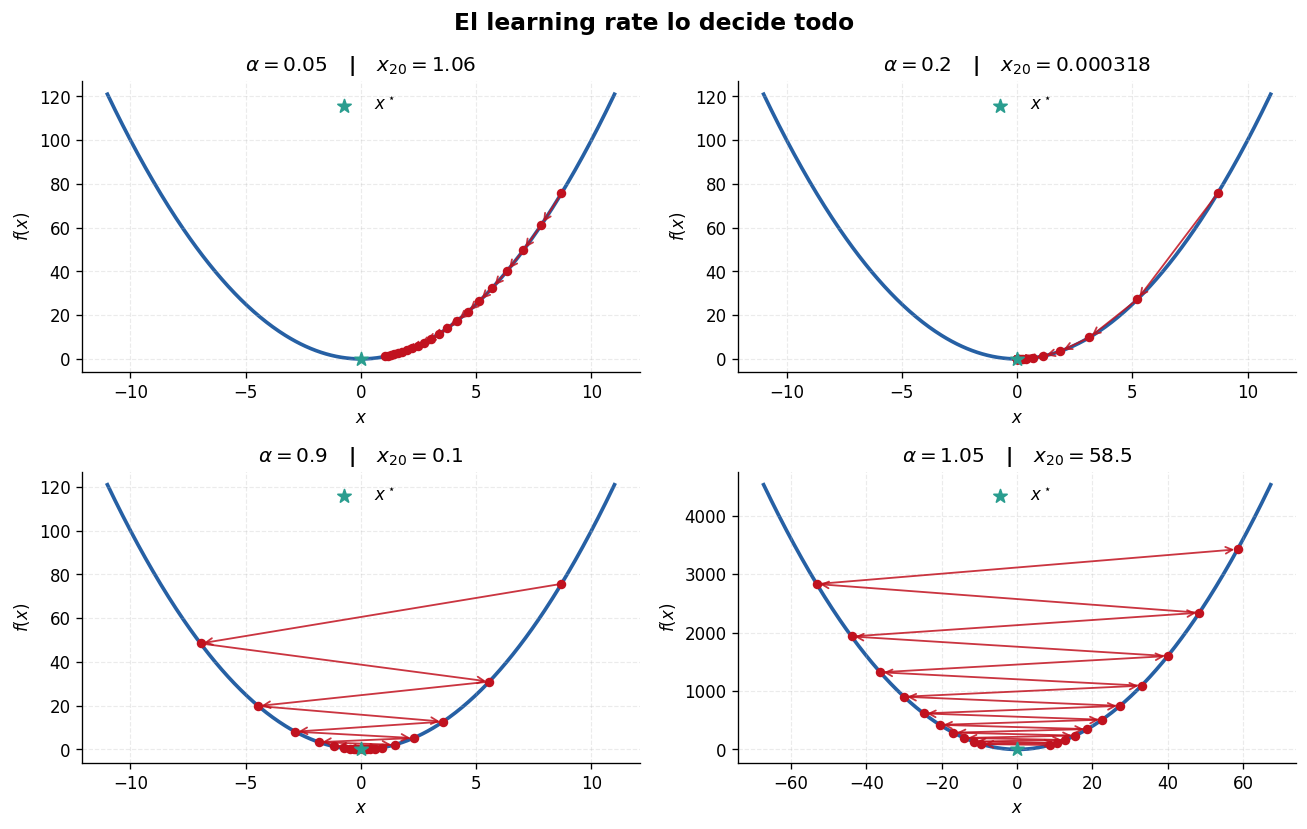

In [3]:
def plot_descent_1d(alpha, x0=8.7, n_iter=20, ax=None, f=f1, grad=grad_f1):
    hist = gradient_descent_1d(grad, x0, alpha, n_iter)
    lim  = max(11.0, 1.15*np.abs(hist).max())
    xs   = np.linspace(-lim, lim, 400)

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(xs, f(xs), color=C["blue"], lw=2.2, zorder=1)

    for a, b in zip(hist[:-1], hist[1:]):
        ax.annotate("", xy=(b, f(b)), xytext=(a, f(a)),
                    arrowprops=dict(arrowstyle="->", color=C["red"], lw=1.1, alpha=0.85))
    ax.scatter(hist, f(hist), s=22, color=C["red"], zorder=3)
    ax.scatter([0], [0], s=70, marker="*", color=C["green"], zorder=4, label=r"$x^\star$")

    ax.set_title(rf"$\alpha = {alpha}$   |   $x_{{{n_iter}}} = {hist[-1]:.3g}$")
    ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)$")
    ax.legend(loc="upper center")
    return hist

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, a in zip(axes.ravel(), [0.05, 0.2, 0.9, 1.05]):
    plot_descent_1d(a, ax=ax)
fig.suptitle("El learning rate lo decide todo", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

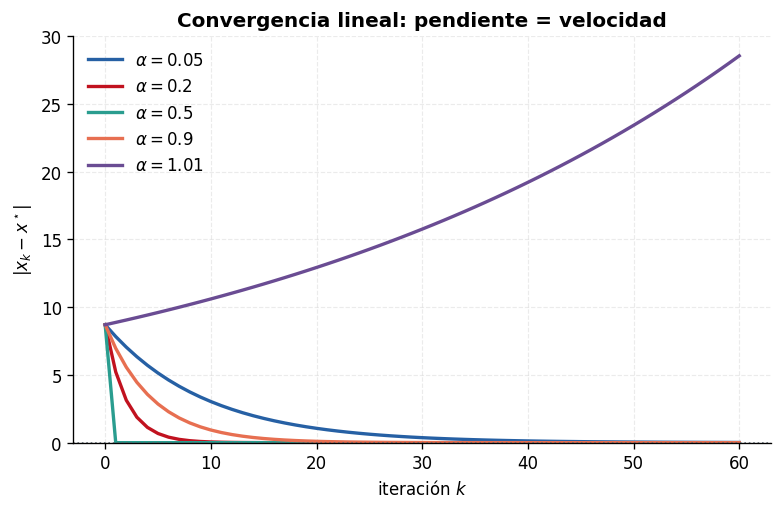

In [23]:
# --- Curvas de convergencia (escala log) -------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for a, col in zip([0.05, 0.2, 0.5, 0.9, 1.01], PALETTE):
    hist = gradient_descent_1d(grad_f1, 8.7, a, n_iter=60)
    err  = np.abs(hist)                       # |x_k - x*| con x* = 0
    ax.plot(err + 1e-300, color=col, label=rf"$\alpha={a}$")

ax.axhline(1e-8, color=C["gray"], ls=":", lw=1)
ax.set_xlabel("iteración $k$"); ax.set_ylabel(r"$|x_k - x^\star|$")
ax.set_title("Convergencia lineal: pendiente = velocidad")
ax.set_ylim(1e-12, 30); ax.legend()
plt.show()

In [6]:
from ipywidgets import interact, FloatSlider

@interact(alpha=FloatSlider(min=0.01, max=1.10, step=0.01, value=0.20,
                            description=r"$\alpha$", continuous_update=False),
          x0=FloatSlider(min=-10, max=10, step=0.1, value=8.7,
                          description="$x_0$", continuous_update=False))
def _demo(alpha, x0):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    plot_descent_1d(alpha, x0=x0, n_iter=20, ax=ax)
    plt.show()

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='$\\alpha$', max=1.1, min=0.…

---
# 2. Descenso de gradiente en 2D

Ahora $x \in \mathbb{R}^2$ y el gradiente es un **vector** que apunta en la dirección de máximo
crecimiento. Nos movemos en dirección contraria:

$$x_{k+1} = x_k - \alpha\, \nabla f(x_k)$$

Usaremos la **forma cuadrática** canónica:

$$f(x) = \tfrac{1}{2}\,x^\top A\, x - b^\top x
\qquad\Longrightarrow\qquad
\nabla f(x) = A x - b$$

con $A$ simétrica definida positiva. Su mínimo es la solución del sistema lineal $Ax = b$.

In [34]:
class Quadratic:
    '''f(x) = 1/2 x'Ax - b'x  con A simétrica definida positiva.'''
    def __init__(self, A, b=None):
        self.A = np.asarray(A, float)
        self.b = np.zeros(self.A.shape[0]) if b is None else np.asarray(b, float)
        self.x_star = np.linalg.solve(self.A, self.b)
        self.eigs   = np.linalg.eigvalsh(self.A)
        self.kappa  = self.eigs.max() / self.eigs.min()   # número de condición

    def __call__(self, x):
        x = np.atleast_2d(x)
        return 0.5*np.einsum("ij,jk,ik->i", x, self.A, x) - x @ self.b

    def grad(self, x):
        return self.A @ x - self.b


def gradient_descent(fun, x0, alpha, n_iter=50, tol=1e-12):
    x = np.array(x0, float)
    hist = [x.copy()]
    for _ in range(n_iter):
        g = fun.grad(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - alpha * g
        hist.append(x.copy())
    return np.array(hist)


def plot_contours(fun, ax, lim=10, n=300, levels=12, cmap="viridis"):
    g = np.linspace(-lim, lim, n)
    X1, X2 = np.meshgrid(g, g)
    Z = np.array([fun(np.c_[X1.ravel(), X2.ravel()])]).reshape(X1.shape)
    cs = ax.contour(X1, X2, Z, levels=levels, cmap=cmap, linewidths=1.0)
    ax.scatter(*fun.x_star, marker="*", s=140, color=C["green"], zorder=5, label=r"$x^\star$")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
    return cs


def plot_path(hist, ax, color=C["red"], label=None, ms=18):
    ax.plot(hist[:, 0], hist[:, 1], "-", color=color, lw=1.3, alpha=0.9, label=label)
    ax.scatter(hist[:, 0], hist[:, 1], s=ms, color=color, zorder=4)
    ax.scatter(*hist[0], s=60, marker="o", facecolor="white",
               edgecolor=color, lw=1.6, zorder=6)

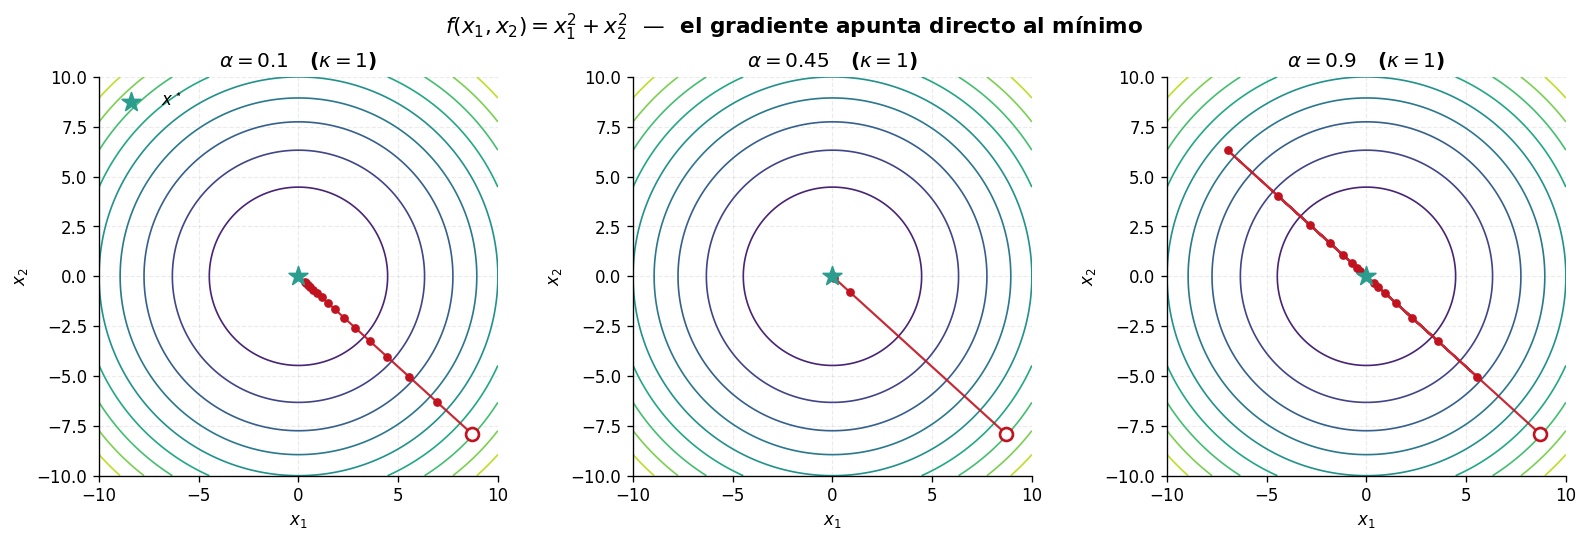

In [35]:
# f(x1,x2) = x1^2 + x2^2   ->   A = 2I  (curvas de nivel = circunferencias)
q_iso = Quadratic(A=2*np.eye(2))
x0 = np.array([8.7, -7.9])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, a in zip(axes, [0.1, 0.45, 0.9]):
    plot_contours(q_iso, ax)
    hist = gradient_descent(q_iso, x0, alpha=a, n_iter=15)
    plot_path(hist, ax)
    ax.set_title(rf"$\alpha = {a}$   ($\kappa = {q_iso.kappa:.0f}$)")
axes[0].legend(loc="upper left")
fig.suptitle(r"$f(x_1,x_2)=x_1^2+x_2^2$  —  el gradiente apunta directo al mínimo",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---
# 3. El número de condición: ¿Por qué algunos problemas son difíciles?

Cuando las curvas de nivel dejan de ser circunferencias y se vuelven **elipses alargadas**,
el gradiente ya **no apunta al mínimo**: apunta perpendicular a la curva de nivel local.
El resultado es el famoso **zig-zag**.

La medida de "cuán alargado" es el problema es el **número de condición**:

$$\kappa(A) = \frac{\lambda_{\max}(A)}{\lambda_{\min}(A)} \;\ge\; 1$$

y la teoría dice que el error decae como

$$\|x_k - x^\star\|_A \;\le\; \left(\frac{\kappa-1}{\kappa+1}\right)^{k}\|x_0-x^\star\|_A$$

**$\kappa$ grande = convergencia lenta.

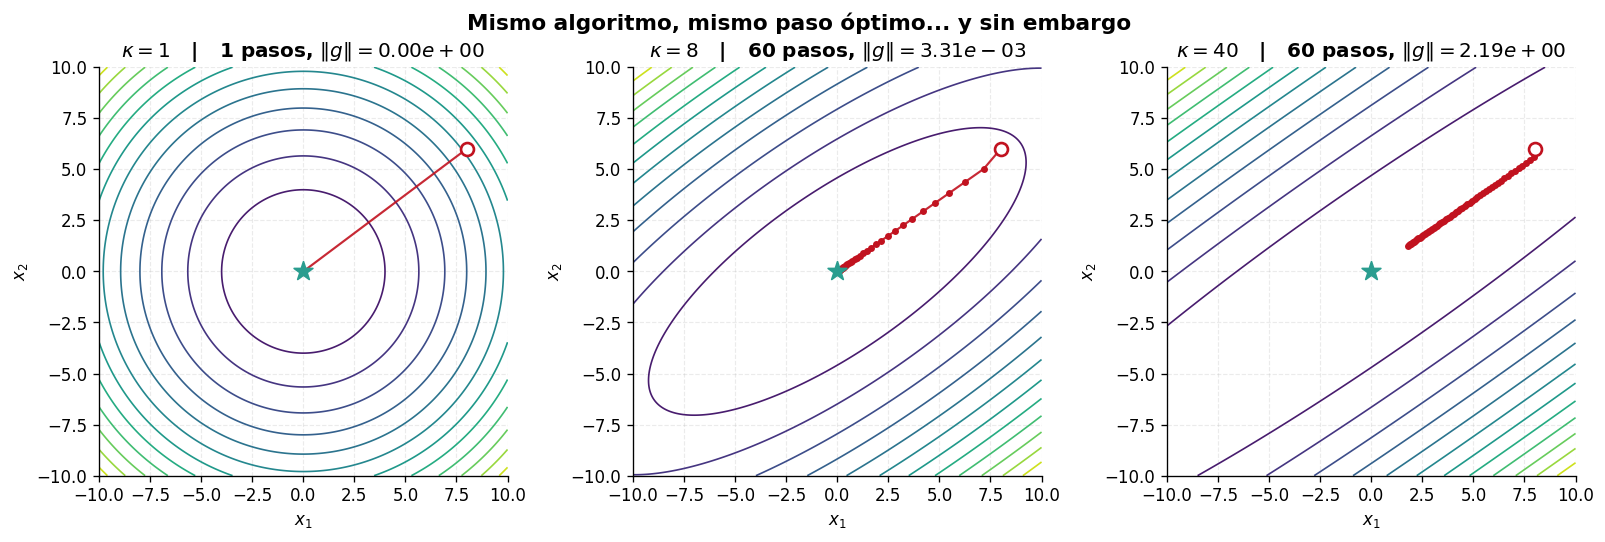

In [36]:
def rotated_quadratic(kappa, theta=np.deg2rad(35)):
    '''Cuadrática con número de condición 'kappa' y ejes rotados 'theta'.'''
    Q = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    D = np.diag([1.0, kappa])
    return Quadratic(A=Q @ D @ Q.T)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, k in zip(axes, [1, 8, 40]):
    q = rotated_quadratic(k)
    plot_contours(q, ax, lim=10, levels=14)
    alpha = 1.0 / q.eigs.max()          # el mayor paso "seguro" (alpha < 2/L)
    hist = gradient_descent(q, np.array([8.0, 6.0]), alpha=alpha, n_iter=60)
    plot_path(hist, ax, ms=10)
    ax.set_title(rf"$\kappa = {k}$   |   {len(hist)-1} pasos, $\|g\|={np.linalg.norm(q.grad(hist[-1])):.2e}$")
fig.suptitle("Mismo algoritmo, mismo paso óptimo... y sin embargo", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

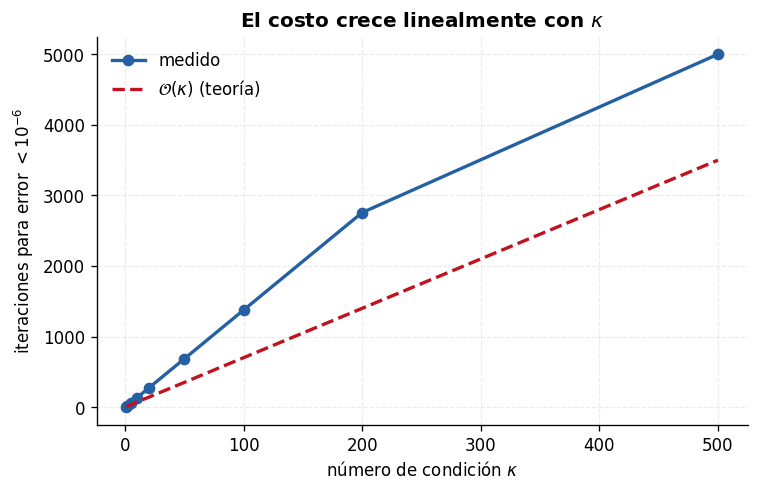

In [37]:
# ¿Cuántas iteraciones necesitamos para bajar el error 1e-6? 
kappas = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
iters  = []
for k in kappas:
    q = rotated_quadratic(k)
    hist = gradient_descent(q, np.array([8.0, 6.0]), alpha=1.0/q.eigs.max(), n_iter=5000)
    err  = np.linalg.norm(hist - q.x_star, axis=1) / np.linalg.norm(hist[0] - q.x_star)
    idx  = np.argmax(err < 1e-6)
    iters.append(idx if idx > 0 else len(err))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(kappas, iters, "o-", color=C["blue"], label="medido")
ax.plot(kappas, 7*kappas, "--", color=C["red"], label=r"$\mathcal{O}(\kappa)$ (teoría)")
ax.set_xlabel(r"número de condición $\kappa$")
ax.set_ylabel(r"iteraciones para error $<10^{-6}$")
ax.set_title("El costo crece linealmente con $\\kappa$")
ax.legend()
plt.show()

---
# 4. Steepest Descent: elegir $\alpha_k$ de forma óptima

En vez de fijar $\alpha$ a ojo, lo elegimos como **el mejor paso posible** en la dirección
actual $d_k = \nabla f(x_k)$:

$$\alpha_k = \arg\min_\alpha \; \phi(\alpha),\qquad \phi(\alpha)= f\big(x_k - \alpha \nabla f(x_k)\big)$$

Para la cuadrática, $\phi$ es una parábola en $\alpha$. Expandiendo y derivando (tal como
en la diapositiva):

$$\phi'(\alpha) = \alpha\, \nabla f_k^\top A \nabla f_k - \nabla f_k^\top \nabla f_k = 0
\qquad\Longrightarrow\qquad
\boxed{\;\alpha_k = \frac{\nabla f_k^\top \nabla f_k}{\nabla f_k^\top A\, \nabla f_k}\;}$$


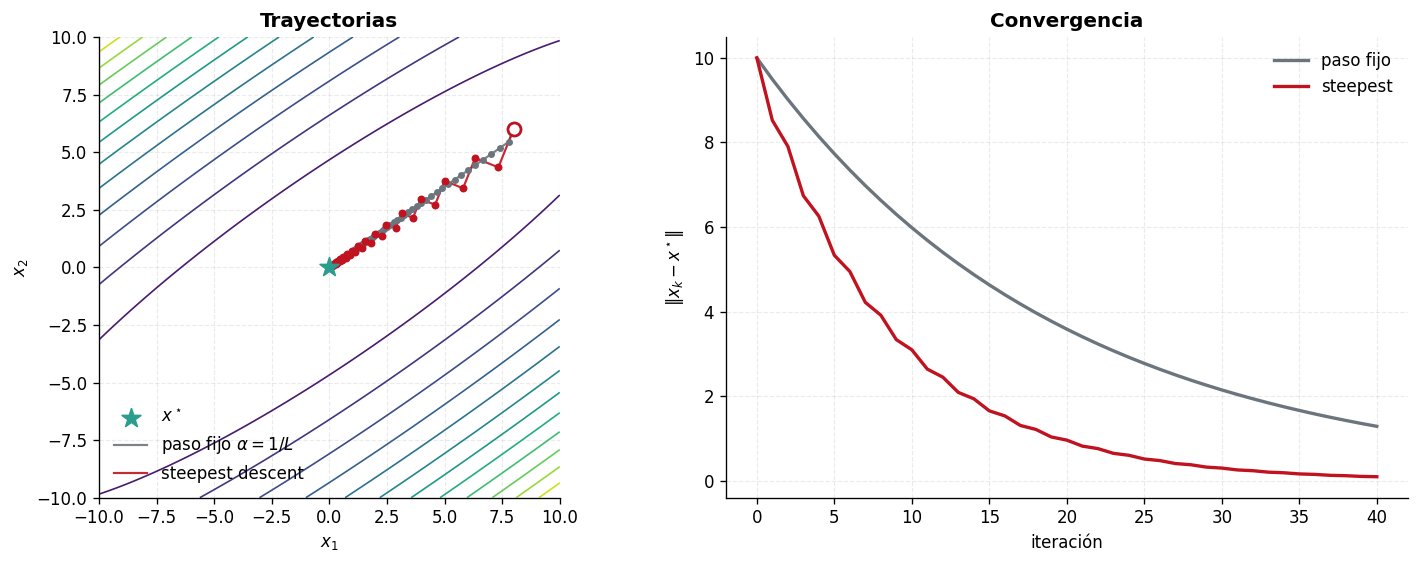

cos(ángulo) entre gradientes consecutivos:
[ 0.  0. -0.  0.  0.]


In [ ]:
def steepest_descent(fun, x0, n_iter=50, tol=1e-12):
    x = np.array(x0, float)
    hist, alphas = [x.copy()], []
    for _ in range(n_iter):
        g = fun.grad(x)
        gg = # TO DO
        if np.sqrt(gg) < tol:
            break
        a = # TO DO       # búsqueda exacta 
        x = x - a*g
        hist.append(x.copy()); alphas.append(a)
    return np.array(hist), np.array(alphas)

q = rotated_quadratic(20)
x0 = np.array([8.0, 6.0])

h_fix    = gradient_descent(q, x0, alpha=1.0/q.eigs.max(), n_iter=40)
h_sd, al = steepest_descent(q, x0, n_iter=40)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

plot_contours(q, axes[0], lim=10, levels=14)
plot_path(h_fix, axes[0], color=C["gray"],  label=r"paso fijo $\alpha=1/L$", ms=10)
plot_path(h_sd,  axes[0], color=C["red"],   label="steepest descent", ms=14)
axes[0].legend(loc="lower left"); axes[0].set_title("Trayectorias")

for h, c, lb in [(h_fix, C["gray"], "paso fijo"), (h_sd, C["red"], "steepest")]:
    e = np.linalg.norm(h - q.x_star, axis=1)
    axes[1].plot(e + 1e-300, color=c, label=lb)
axes[1].set_xlabel("iteración"); axes[1].set_ylabel(r"$\|x_k-x^\star\|$")
axes[1].set_title("Convergencia"); axes[1].legend()
fig.tight_layout(); plt.show()

# Verificación numérica de la ortogonalidad
g = np.array([q.grad(x) for x in h_sd[:6]])
print("cos(ángulo) entre gradientes consecutivos:")
print(np.round([g[i] @ g[i+1] / (np.linalg.norm(g[i])*np.linalg.norm(g[i+1]))
                for i in range(len(g)-1)], 12))

## 5. Gradiente Conjugado (CG): Direcciones $A$-conjugadas

Para evitar el zig-zag repetitivo de *Steepest Descent* en problemas mal condicionados ($\kappa \gg 1$), el método de **Gradiente Conjugado** exige que las direcciones de búsqueda consecutivas sean **ortogonales respecto a la matriz $A$** ($A$-conjugadas):

$$d_i^\top A d_j = 0 \quad \forall i \neq j$$

Esto garantiza que al minimizar a lo largo de una dirección $d_k$, no se deshaga el progreso obtenido en las direcciones anteriores, convergiendo a la solución exacta en a lo más **$n$ iteraciones** para un problema cuadrático en $\mathbb{R}^n$.

---

**Actualizaciones del algoritmo (para $f(x) = \frac{1}{2} x^\top A x - b^\top x$):**

1. **Residuo inicial y dirección:**
   $$r_0 = b - A x_0 = -\nabla f(x_0), \qquad d_0 = r_0$$

2. **Tamaño de paso óptimo $\alpha_k$:**
   $$\alpha_k = \frac{r_k^\top r_k}{d_k^\top A d_k}$$

3. **Actualización de posición y residuo:**
   $$x_{k+1} = x_k + \alpha_k d_k, \qquad r_{k+1} = r_k - \alpha_k A d_k$$

4. **Factor de corrección $\beta_k$ (Fletcher-Reeves):**
   $$\beta_k = \frac{r_{k+1}^\top r_{k+1}}{r_k^\top r_k}$$

5. **Nueva dirección conjugada:**
   $$d_{k+1} = r_{k+1} + \beta_k d_k$$

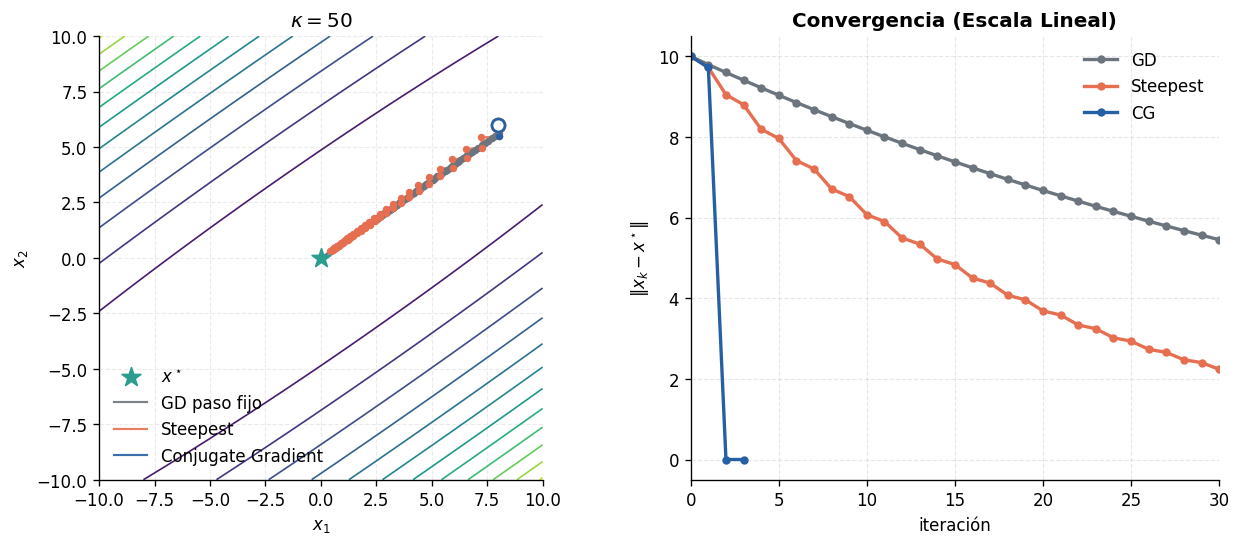

In [ ]:
def conjugate_gradient(fun, x0, n_iter=50, tol=1e-14):
    x = np.array(x0, float)
    r = # TO DO       # residuo = -gradiente
    d = r.copy()
    hist = [x.copy()]
    rs = r @ r
    for _ in range(n_iter):
        if np.sqrt(rs) < tol:
            break
        Ad = fun.A @ d
        a  = # TO DO
        x  = # TO DO
        r  = # TO DO
        rs_new = r @ r
        d  = r + (rs_new/rs) * d
        rs = rs_new
        hist.append(x.copy())
    return np.array(hist)

q  = rotated_quadratic(50)
x0 = np.array([8.0, 6.0])

h_gd     = gradient_descent(q, x0, alpha=1.0/q.eigs.max(), n_iter=60)
h_sd, _  = steepest_descent(q, x0, n_iter=60)
h_cg     = conjugate_gradient(q, x0, n_iter=60)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
plot_contours(q, axes[0], lim=10, levels=14)
for h, c, lb in [(h_gd, C["gray"], "GD paso fijo"),
                 (h_sd, C["orange"], "Steepest"),
                 (h_cg, C["blue"], "Conjugate Gradient")]:
    plot_path(h, axes[0], color=c, label=lb, ms=12)
axes[0].legend(loc="lower left"); axes[0].set_title(rf"$\kappa={q.kappa:.0f}$")

for h, c, lb in [(h_gd, C["gray"], "GD"), (h_sd, C["orange"], "Steepest"), (h_cg, C["blue"], "CG")]:
    err = np.linalg.norm(h - q.x_star, axis=1)
    axes[1].plot(err, color=c, label=lb, marker="o", markersize=4)

axes[1].set_xlabel("iteración")
axes[1].set_ylabel(r"$\|x_k-x^\star\|$")
axes[1].set_xlim(0, 30)  
axes[1].set_title("Convergencia (Escala Lineal)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

## 🎯 Reto 2

Genera una cuadrática aleatoria en $\mathbb{R}^{50}$ (`A = M @ M.T + 0.1*I` con `M` aleatoria)
y compara el número de iteraciones de GD, Steepest y CG para llegar a $\|r\|<10^{-8}$.
¿Se cumple que CG termina en $\le 50$ pasos?

In [ ]:



n = # TO DO
M = # TO DO
A = # TO DO
b = #TO DO
q50 = Quadratic(A, b)
print("kappa =", f"{q50.kappa:.1f}")

# --- Solución ---
x0 = np.zeros(n)
tol = # TO DO
max_iter = #TO DO

# 1. Ejecutar los tres algoritmos
h_gd = gradient_descent(q50, x0, alpha=1.0 / q50.eigs.max(), n_iter=max_iter, tol=tol)
h_sd, _ = steepest_descent(q50, x0, n_iter=max_iter, tol=tol)
h_cg = conjugate_gradient(q50, x0, n_iter=max_iter, tol=tol)

iter_gd = len(h_gd) - 1
iter_sd = len(h_sd) - 1
iter_cg = len(h_cg) - 1

print(f"Iteraciones GD (paso fijo): {iter_gd}")
print(f"Iteraciones Steepest:        {iter_sd}")
print(f"Iteraciones CG:              {iter_cg}")
print(f"\n¿CG terminó en <= 50 pasos?  {iter_cg <= n} ({iter_cg} iteraciones)")

kappa = 34.0


---
# 6. Más allá de lo convexo: optimizadores modernos

En redes neuronales la superficie de costo **no es convexa** (recuerda la diapositiva del
*loss landscape*). Los optimizadores modernos añaden dos ideas:

| Idea | Qué hace | Métodos |
|---|---|---|
| **Momentum** | acumula velocidad, atraviesa valles estrechos | SGD+Momentum, NAG |
| **Paso adaptativo** | escala el paso por coordenada según la historia del gradiente | AdaGrad, RMSProp |
| **Ambas** | momentum + adaptativo + corrección de sesgo | **Adam** |

Los probamos en la función de **Rosenbrock**, el clásico "valle en banana":
$$f(x_1,x_2) = (1-x_1)^2 + 100\,(x_2-x_1^2)^2, \qquad x^\star = (1,1)$$

In [41]:
def rosenbrock(x):
    x = np.atleast_2d(x)
    return (1-x[:,0])**2 + 100*(x[:,1]-x[:,0]**2)**2

def rosenbrock_grad(x):
    x1, x2 = x
    return np.array([-2*(1-x1) - 400*x1*(x2 - x1**2),
                      200*(x2 - x1**2)])

# ---------------- Optimizadores (todos en ~5 líneas cada uno) ----------------
def optimize(grad, x0, method="sgd", lr=1e-3, n_iter=2000,
             beta=0.9, beta2=0.999, eps=1e-8):
    x = np.array(x0, float)
    v = np.zeros_like(x); s = np.zeros_like(x)
    hist = [x.copy()]
    for t in range(1, n_iter+1):
        g = grad(x)
        if   method == "sgd":
            step = lr*g
        elif method == "momentum":
            v = beta*v + g
            step = lr*v
        elif method == "nesterov":
            v = beta*v + g
            step = lr*(beta*v + (1-beta)*g)
        elif method == "adagrad":
            s += g**2
            step = lr*g/(np.sqrt(s)+eps)
        elif method == "rmsprop":
            s = beta*s + (1-beta)*g**2
            step = lr*g/(np.sqrt(s)+eps)
        elif method == "adam":
            v = beta*v  + (1-beta)*g
            s = beta2*s + (1-beta2)*g**2
            vh = v/(1-beta**t); sh = s/(1-beta2**t)
            step = lr*vh/(np.sqrt(sh)+eps)
        else:
            raise ValueError(method)
        x = x - step
        hist.append(x.copy())
        if not np.all(np.isfinite(x)):
            break
    return np.array(hist)

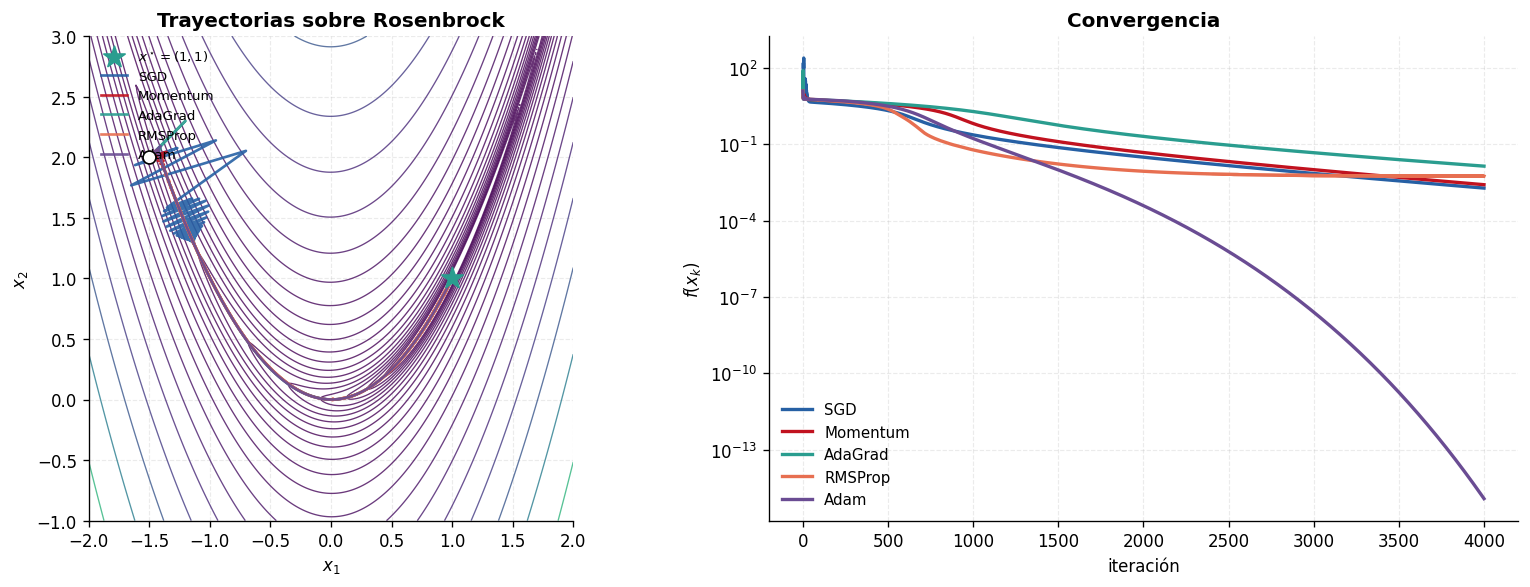

método      x_final                     f(x_final)
SGD         [0.9565 0.9147]             1.896e-03
Momentum    [0.9492 0.9009]             2.580e-03
AdaGrad     [0.8824 0.7782]             1.384e-02
RMSProp     [0.9928 0.9783]             5.635e-03
Adam        [1. 1.]                     1.173e-15


In [ ]:
x0 = np.array([-1.5, 2.0])
runs = {
    "SGD":       optimize(rosenbrock_grad, x0, "sgd",      lr=1.5e-3, n_iter=4000),
    "Momentum":  optimize(rosenbrock_grad, x0, "momentum", lr=1.5e-4, n_iter=4000),
    "AdaGrad":   optimize(rosenbrock_grad, x0, "adagrad",  lr=3e-1,   n_iter=4000),
    "RMSProp":   optimize(rosenbrock_grad, x0, "rmsprop",  lr=5e-3,   n_iter=4000),
    "Adam":      optimize(rosenbrock_grad, x0, "adam",     lr=1.5e-2, n_iter=4000),
}

# ----- Figura: trayectorias + convergencia -----------------------------------
fig = plt.figure(figsize=(13.5, 5.0))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

g1 = np.linspace(-2.0, 2.0, 400); g2 = np.linspace(-1.0, 3.0, 400)
X1, X2 = np.meshgrid(g1, g2)
Z = rosenbrock(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape)
ax1.contour(X1, X2, Z, levels=np.logspace(-0.5, 3.5, 22),
            cmap="viridis", linewidths=0.8, alpha=0.8)
ax1.scatter([1], [1], marker="*", s=180, color=C["green"], zorder=6, label=r"$x^\star=(1,1)$")
ax1.scatter(*x0, s=60, facecolor="white", edgecolor="k", zorder=6)

for (name, h), c in zip(runs.items(), PALETTE):
    ax1.plot(h[:, 0], h[:, 1], color=c, lw=1.6, alpha=0.9, label=name)
    ax2.semilogy(rosenbrock(h) + 1e-300, color=c, label=name)

ax1.set_xlim(-2, 2); ax1.set_ylim(-1, 3); ax1.set_aspect("equal")
ax1.set_xlabel("$x_1$"); ax1.set_ylabel("$x_2$")
ax1.set_title("Trayectorias sobre Rosenbrock"); ax1.legend(loc="upper left", fontsize=8)

ax2.set_xlabel("iteración"); ax2.set_ylabel("$f(x_k)$")
ax2.set_title("Convergencia"); ax2.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"{'método':<12}{'x_final':<28}{'f(x_final)'}")
for name, h in runs.items():
    print(f"{name:<12}{str(np.round(h[-1],4)):<28}{rosenbrock(h[-1])[0]:.3e}")

---
# 7. Restricciones: descenso de gradiente proyectado

Las restricciones **conectan el mundo matemático con el mundo físico**: una intensidad no puede
ser negativa, una probabilidad debe sumar 1, una profundidad debe estar en un rango.

$$\min_x f(x) \quad \text{s.a.} \quad x \in \mathcal{C}$$

Si sabemos **proyectar** sobre el conjunto $\mathcal{C}$, el algoritmo es casi el mismo:

$$x_{k+1} = \Pi_{\mathcal{C}}\big(x_k - \alpha \nabla f(x_k)\big)$$

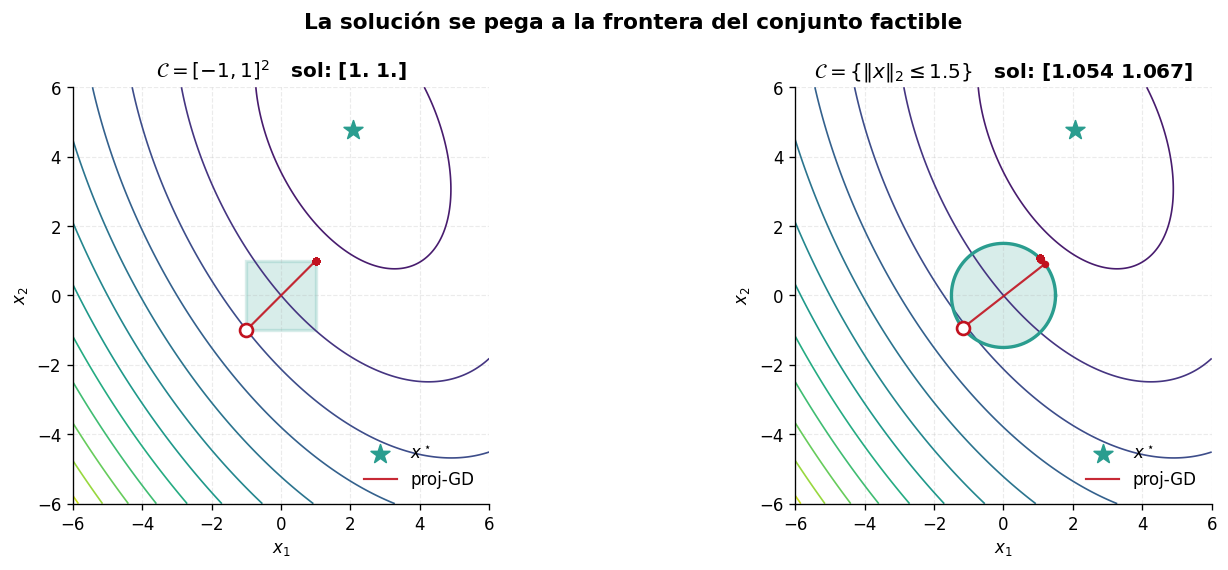

In [42]:
def project_box(x, lo, hi):
    return np.clip(x, lo, hi)

def project_ball(x, radius=1.0, center=np.zeros(2)):
    d = x - center
    n = np.linalg.norm(d)
    return center + d*(radius/n) if n > radius else x

def projected_gd(fun, x0, alpha, proj, n_iter=60):
    x = proj(np.array(x0, float))
    hist = [x.copy()]
    for _ in range(n_iter):
        x = proj(x - alpha*fun.grad(x))
        hist.append(x.copy())
    return np.array(hist)

# Cuadrática cuyo mínimo SIN restricciones cae fuera del conjunto factible
q = Quadratic(A=np.array([[2.0, 0.6], [0.6, 1.0]]), b=np.array([7.0, 6.0]))
alpha = 1.0/q.eigs.max()
x0 = np.array([-2.5, -2.0])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# (a) caja  -1 <= x <= 1
h = projected_gd(q, x0, alpha, lambda z: project_box(z, -1, 1), n_iter=60)
plot_contours(q, axes[0], lim=6, levels=16)
axes[0].add_patch(plt.Rectangle((-1, -1), 2, 2, facecolor=C["green"],
                                alpha=0.18, edgecolor=C["green"], lw=2))
plot_path(h, axes[0], ms=12, label="proj-GD")
axes[0].set_title(r"$\mathcal{C}=[-1,1]^2$" + f"   sol: {np.round(h[-1],3)}")
axes[0].legend(loc="lower right")

# (b) bola  ||x|| <= 1.5
h = projected_gd(q, x0, alpha, lambda z: project_ball(z, 1.5), n_iter=60)
plot_contours(q, axes[1], lim=6, levels=16)
th = np.linspace(0, 2*np.pi, 200)
axes[1].fill(1.5*np.cos(th), 1.5*np.sin(th), color=C["green"], alpha=0.18)
axes[1].plot(1.5*np.cos(th), 1.5*np.sin(th), color=C["green"], lw=2)
plot_path(h, axes[1], ms=12, label="proj-GD")
axes[1].set_title(r"$\mathcal{C}=\{\|x\|_2\leq 1.5\}$" + f"   sol: {np.round(h[-1],3)}")
axes[1].legend(loc="lower right")

fig.suptitle("La solución se pega a la frontera del conjunto factible",
             fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

---
# 8. Diferenciación automática: el gradiente gratis

Hasta ahora derivamos **a mano**. Eso no escala a una red con millones de parámetros.
La diferenciación automática (AD) construye un **grafo computacional** y aplica la regla
de la cadena hacia atrás (*backpropagation*), obteniendo el gradiente exacto
(no aproximado, como en diferencias finitas) y a costo comparable al del *forward*.

Comparemos las tres formas de derivar:

In [ ]:
def numerical_grad(f, x, h=1e-5):
    '''Diferencias finitas centradas.'''
    x = np.array(x, float); g = np.zeros_like(x)
    for i in range(x.size):
        e = np.zeros_like(x); e[i] = h
        g[i] = (f(x+e) - f(x-e)) / (2*h)
    return g

x_test = np.array([-1.5, 2.0])
f_scalar = lambda z: float(rosenbrock(z)[0])

print("Analítico :", rosenbrock_grad(x_test))
print("Numérico  :", numerical_grad(f_scalar, x_test))

try:
    import torch
    xt = torch.tensor(x_test, requires_grad=True, dtype=torch.float64)
    ft = (1-xt[0])**2 + 100*(xt[1]-xt[0]**2)**2
    ft.backward()
    print("Autodiff  :", xt.grad.numpy())
except ImportError:
    print("Autodiff  : (PyTorch no instalado — 'pip install torch' para probarlo)")

Analítico : [-155.  -50.]
Numérico  : [-155.00000006  -50.        ]
Autodiff  : [-155.  -50.]


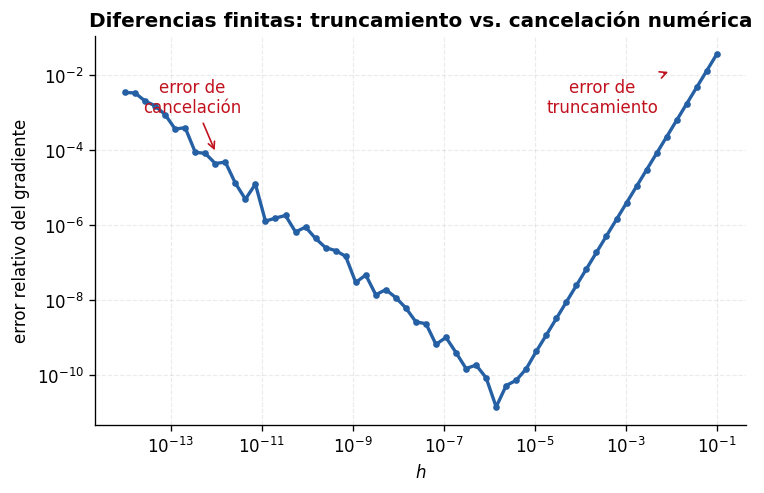

In [43]:
# --- ¿Por qué las diferencias finitas son mala idea? -------------------------
hs   = np.logspace(-14, -1, 60)
true = rosenbrock_grad(x_test)
err  = [np.linalg.norm(numerical_grad(f_scalar, x_test, h) - true)/np.linalg.norm(true)
        for h in hs]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(hs, err, "o-", ms=3, color=C["blue"])
ax.set_xlabel("$h$"); ax.set_ylabel("error relativo del gradiente")
ax.set_title("Diferencias finitas: truncamiento vs. cancelación numérica")
ax.annotate("error de\ncancelación", xy=(1e-12, err[8]), xytext=(3e-13, 1e-3),
            arrowprops=dict(arrowstyle="->", color=C["red"]), color=C["red"], ha="center")
ax.annotate("error de\ntruncamiento", xy=(1e-2, err[-2]), xytext=(3e-4, 1e-3),
            arrowprops=dict(arrowstyle="->", color=C["red"]), color=C["red"], ha="center")
plt.show()